# Startup Outcome Classification — Cross-Validated Pipeline

**Research question:** Does accounting for unsupervised structure (K-Means clustering) improve supervised classification of startup outcomes?

**Approach:**
1. Baseline classifiers: Logistic Regression, SVM, MLP
2. Hybrid classifiers: same models with K-Means cluster features appended
3. Evaluation via **5-fold stratified cross-validation** on a development set
4. Final honest evaluation on a **held-out test set (vault)** — opened once only

---

## Cell 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import f1_score, roc_auc_score, classification_report
from matplotlib.patches import Patch

## Cell 2 — Load & Preprocess

Key steps:
- Drop identifier columns and leaky columns (`labels`, `closed_at`)
- Impute missing milestone years with 0, add a `has_milestone` flag
- Encode target: `acquired → 1`, `closed → 0`

In [7]:
df = pd.read_csv('/Users/Matthew/Desktop/repositories/ml/CompFinanceML/data/startup_data.csv')

# Columns to drop: identifiers, duplicates, raw dates (captured in age_ cols), and leakers
drop_cols = [
    'Unnamed: 0', 'Unnamed: 6', 'id', 'object_id', 'name',
    'zip_code', 'city', 'state_code', 'state_code.1',
    'closed_at',        # closed_at leaks outcome — only filled for failures
    'first_funding_at', 'last_funding_at',
    'category_code',
    'labels'                           # labels IS the target encoded — pure leakage
]
df = df.drop(columns=drop_cols)
df = df.rename(columns={'status': 'outcome'})
df['founded_at'] = pd.to_datetime(df['founded_at'], errors='coerce')
# Missing milestone years mean the company had no milestones — fill with 0
df['has_milestone']              = df['age_first_milestone_year'].notna().astype(int)
df['age_first_milestone_year']   = df['age_first_milestone_year'].fillna(0)
df['age_last_milestone_year']    = df['age_last_milestone_year'].fillna(0)

# Binary target
df['outcome'] = df['outcome'].map({'acquired': 1, 'closed': 0})

X = df.drop(columns=['outcome'])
y = df['outcome'].values

print(f"Dataset shape : {df.shape}")
print(f"Class balance : Closed={( y==0).sum()}  Acquired={(y==1).sum()}")

Dataset shape : (923, 36)
Class balance : Closed=326  Acquired=597


## Cell 3 — Train / Test Split (The Vault)

We hold out **20% as a final test set** that is **never touched** until the very end.
All model development and comparison happens on the remaining 80% via cross-validation.

> ⚠️ Do not evaluate on `X_test` until Cell 8.

In [3]:
X_dev, X_test, y_dev, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          # preserves class proportions in both splits
)

print(f"Development set : {X_dev.shape[0]} samples")
print(f"Final test set  : {X_test.shape[0]} samples  "
      f"(Closed={( y_test==0).sum()}, Acquired={(y_test==1).sum()})")

Development set : 738 samples
Final test set  : 185 samples  (Closed=65, Acquired=120)


## Cell 4 — Cross-Validation Setup

**Why cross-validation?**  
With only ~740 development samples, a single train/val split gives unreliable estimates (the result depends heavily on which 140 samples land in the val set). Stratified 5-fold CV rotates through all samples — every sample is validated exactly once — and reports **mean ± std**, which is far more trustworthy.

**Key design principle:**  
Inside each fold, the `StandardScaler` *and* `KMeans` are both fit on the training portion only, then applied to the validation portion. This prevents any information from the validation fold leaking into preprocessing.

In [8]:
N_FOLDS    = 5
N_CLUSTERS = 6

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)

def add_cluster_ohe(X_scaled, clusters, n_clusters=N_CLUSTERS):
    """One-hot encode cluster labels and append as extra features."""
    ohe = np.zeros((len(clusters), n_clusters))
    for i, c in enumerate(clusters):
        ohe[i, c] = 1
    return np.hstack([X_scaled, ohe])

# Model templates — cloned fresh at the start of every fold
baseline_models = {
    'LogReg' : LogisticRegression(max_iter=1000, random_state=42),
    'SVM'    : SVC(kernel='rbf', probability=True, random_state=42),
    'MLP'    : MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100,
                              early_stopping=True, random_state=42),
}

hybrid_models = {
    'LR + KMeans'  : LogisticRegression(max_iter=1000, random_state=42),
    'SVM + KMeans' : SVC(kernel='rbf', probability=True, random_state=42),
    'MLP + KMeans' : MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100,
                                    early_stopping=True, random_state=42),
}

print(f"5-fold CV on {X_dev.shape[0]} samples → "
      f"~{int(X_dev.shape[0]*0.8)} train / ~{int(X_dev.shape[0]*0.2)} val per fold")

5-fold CV on 738 samples → ~590 train / ~147 val per fold


## Cell 5 — Run Cross-Validation

For each fold:
1. Scale features (fit on train only)
2. Train and evaluate **baseline** models
3. Fit K-Means on train fold only, append cluster OHE features
4. Train and evaluate **hybrid** models

In [9]:
results   = {name: {'f1': [], 'auc': []} for name in list(baseline_models) + list(hybrid_models)}
X_dev_arr = X_dev.values

for fold, (train_idx, val_idx) in enumerate(skf.split(X_dev_arr, y_dev)):
    print(f"\n--- Fold {fold+1}/{N_FOLDS} ---")

    X_tr, X_val = X_dev_arr[train_idx], X_dev_arr[val_idx]
    y_tr, y_val = y_dev[train_idx],     y_dev[val_idx]

    # ── Step 1: Scale (fit on train fold only) ──────────────────────────────
    scaler       = StandardScaler()
    X_tr_scaled  = scaler.fit_transform(X_tr)
    X_val_scaled = scaler.transform(X_val)   # transform only — no leakage

    # ── Step 2: Baseline models ─────────────────────────────────────────────
    for name, template in baseline_models.items():
        model  = clone(template)
        model.fit(X_tr_scaled, y_tr)
        y_pred = model.predict(X_val_scaled)
        y_prob = model.predict_proba(X_val_scaled)[:, 1]
        f1  = f1_score(y_val, y_pred, average='macro')
        auc = roc_auc_score(y_val, y_prob)
        results[name]['f1'].append(f1)
        results[name]['auc'].append(auc)
        print(f"  {name:<15} F1={f1:.3f}  AUC={auc:.3f}")

    # ── Step 3: K-Means (fit on train fold only) ────────────────────────────
    km = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
    km.fit(X_tr_scaled)
    X_tr_hybrid  = add_cluster_ohe(X_tr_scaled,  km.predict(X_tr_scaled))
    X_val_hybrid = add_cluster_ohe(X_val_scaled, km.predict(X_val_scaled))

    # ── Step 4: Hybrid models ───────────────────────────────────────────────
    for name, template in hybrid_models.items():
        model  = clone(template)
        model.fit(X_tr_hybrid, y_tr)
        y_pred = model.predict(X_val_hybrid)
        y_prob = model.predict_proba(X_val_hybrid)[:, 1]
        f1  = f1_score(y_val, y_pred, average='macro')
        auc = roc_auc_score(y_val, y_prob)
        results[name]['f1'].append(f1)
        results[name]['auc'].append(auc)
        print(f"  {name:<15} F1={f1:.3f}  AUC={auc:.3f}")


--- Fold 1/5 ---


ValueError: could not convert string to float: '4/1/2005'

## Cell 6 — Summarise CV Results

Mean ± std across all 5 folds. The std tells you how stable each model is — a high std means the result depends heavily on which samples happen to land in the val fold.

In [ ]:
print("=" * 65)
print(f"{'Model':<20} {'F1 Mean':>10} {'F1 Std':>10} {'AUC Mean':>10} {'AUC Std':>10}")
print("=" * 65)

summary = {}
for name, scores in results.items():
    f1_mean  = np.mean(scores['f1'])
    f1_std   = np.std(scores['f1'])
    auc_mean = np.mean(scores['auc'])
    auc_std  = np.std(scores['auc'])
    summary[name] = dict(f1_mean=f1_mean, f1_std=f1_std,
                         auc_mean=auc_mean, auc_std=auc_std)
    print(f"{name:<20} {f1_mean:>10.3f} {f1_std:>10.3f} {auc_mean:>10.3f} {auc_std:>10.3f}")

Model                   F1 Mean     F1 Std   AUC Mean    AUC Std
LogReg                    0.704      0.037      0.783      0.048
SVM                       0.727      0.053      0.782      0.032
MLP                       0.712      0.024      0.778      0.042
LR + KMeans               0.713      0.032      0.784      0.046
SVM + KMeans              0.721      0.052      0.782      0.033
MLP + KMeans              0.654      0.045      0.736      0.052


## Cell 7 — Visualise CV Results

Bar chart of mean F1 and AUC with error bars showing ± std across folds.  
Blue = baseline models, Orange = K-Means hybrid models.

/var/folders/rk/fpq7918x15x2cn5r3v6cg5400000gn/T/ipykernel_3918/1445766422.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=25, ha='right')
/var/folders/rk/fpq7918x15x2cn5r3v6cg5400000gn/T/ipykernel_3918/1445766422.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(model_names, rotation=25, ha='right')


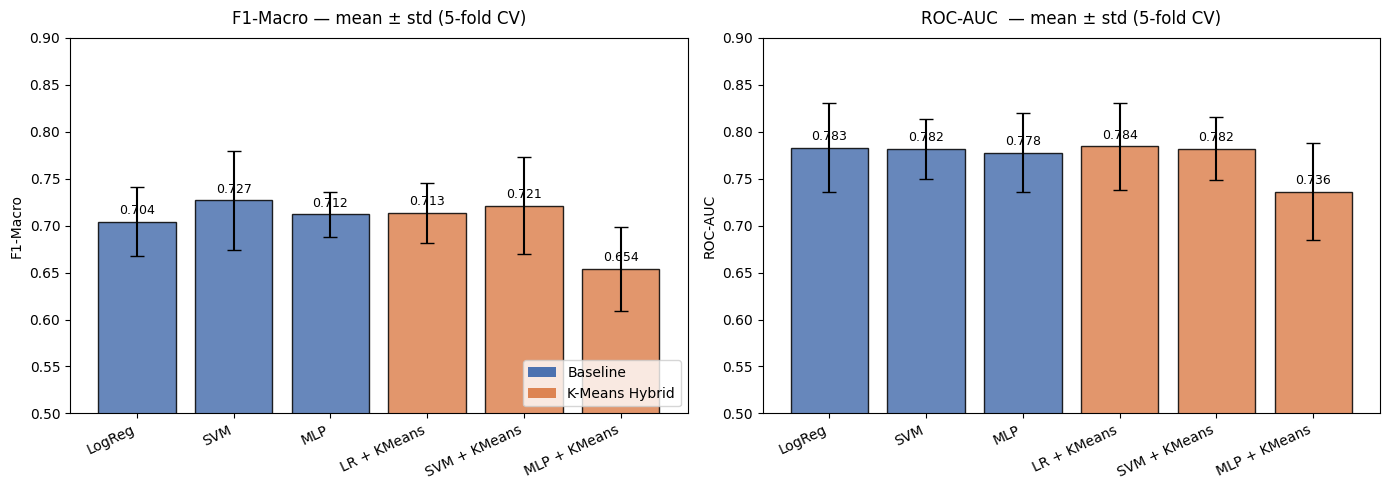

In [ ]:
model_names = list(results.keys())
f1_means    = [summary[n]['f1_mean']  for n in model_names]
f1_stds     = [summary[n]['f1_std']   for n in model_names]
auc_means   = [summary[n]['auc_mean'] for n in model_names]
auc_stds    = [summary[n]['auc_std']  for n in model_names]

colors = ['#4C72B0'] * 3 + ['#DD8452'] * 3   # blue = baseline, orange = hybrid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, means, stds, title, ylabel in [
    (axes[0], f1_means,  f1_stds,  'F1-Macro — mean ± std (5-fold CV)', 'F1-Macro'),
    (axes[1], auc_means, auc_stds, 'ROC-AUC  — mean ± std (5-fold CV)', 'ROC-AUC'),
]:
    bars = ax.bar(model_names, means, yerr=stds, capsize=5,
                  color=colors, alpha=0.85, edgecolor='black')
    ax.set_ylim(0.5, 0.9)
    ax.set_title(title, fontsize=12, pad=10)
    ax.set_ylabel(ylabel)
    ax.set_xticklabels(model_names, rotation=25, ha='right')
    for bar, mean in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{mean:.3f}', ha='center', va='bottom', fontsize=9)

legend_elements = [
    Patch(facecolor='#4C72B0', label='Baseline'),
    Patch(facecolor='#DD8452', label='K-Means Hybrid')
]
axes[0].legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.savefig('cv_results.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell 8 — Final Test Set Evaluation (The Vault)

> ⚠️ **Only run this cell once** — when you are satisfied with your CV analysis and ready to report final numbers.

Here we retrain each model on the **full development set** (all 80%) and evaluate on the held-out 20% test set. This gives the honest final performance estimate.

The scaler and K-Means are fit on the full dev set — the test set is only ever transformed, never used for fitting.

FINAL TEST SET RESULTS

── LogReg ──
              precision    recall  f1-score   support

      Closed       0.62      0.62      0.62        65
    Acquired       0.79      0.80      0.80       120

    accuracy                           0.74       185
   macro avg       0.71      0.71      0.71       185
weighted avg       0.73      0.74      0.73       185

F1 Macro : 0.7084
ROC-AUC  : 0.8040


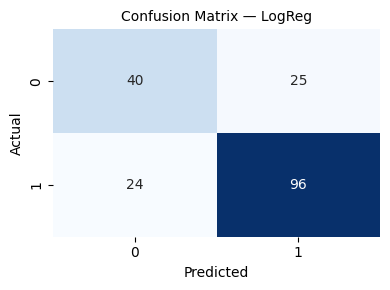


── SVM ──
              precision    recall  f1-score   support

      Closed       0.69      0.51      0.58        65
    Acquired       0.77      0.88      0.82       120

    accuracy                           0.75       185
   macro avg       0.73      0.69      0.70       185
weighted avg       0.74      0.75      0.74       185

F1 Macro : 0.7006
ROC-AUC  : 0.7884


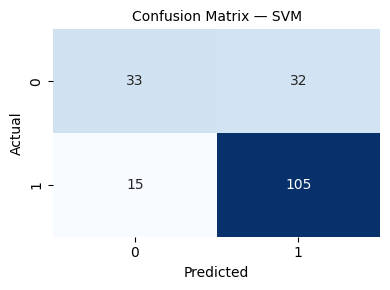


── MLP ──
              precision    recall  f1-score   support

      Closed       0.70      0.43      0.53        65
    Acquired       0.74      0.90      0.82       120

    accuracy                           0.74       185
   macro avg       0.72      0.67      0.67       185
weighted avg       0.73      0.74      0.72       185

F1 Macro : 0.6742
ROC-AUC  : 0.7718


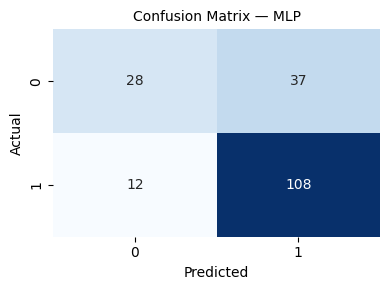


── LR + KMeans ──
              precision    recall  f1-score   support

      Closed       0.64      0.66      0.65        65
    Acquired       0.81      0.80      0.81       120

    accuracy                           0.75       185
   macro avg       0.73      0.73      0.73       185
weighted avg       0.75      0.75      0.75       185

F1 Macro : 0.7291
ROC-AUC  : 0.8062


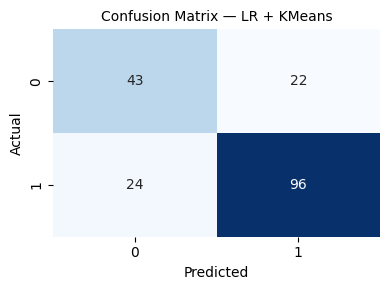


── SVM + KMeans ──
              precision    recall  f1-score   support

      Closed       0.68      0.49      0.57        65
    Acquired       0.76      0.88      0.81       120

    accuracy                           0.74       185
   macro avg       0.72      0.68      0.69       185
weighted avg       0.73      0.74      0.73       185

F1 Macro : 0.6927
ROC-AUC  : 0.7895


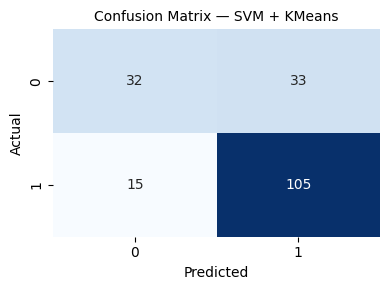


── MLP + KMeans ──
              precision    recall  f1-score   support

      Closed       0.65      0.57      0.61        65
    Acquired       0.78      0.83      0.81       120

    accuracy                           0.74       185
   macro avg       0.72      0.70      0.71       185
weighted avg       0.73      0.74      0.74       185

F1 Macro : 0.7065
ROC-AUC  : 0.7817


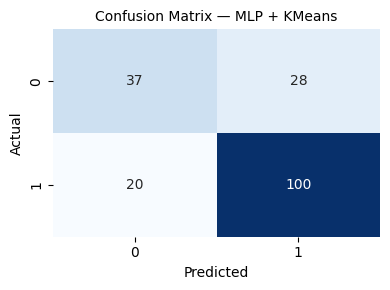

In [ ]:
# ── Fit scaler and K-Means on full development set ──────────────────────────
final_scaler  = StandardScaler()
X_dev_scaled  = final_scaler.fit_transform(X_dev_arr)
X_test_scaled = final_scaler.transform(X_test.values)

final_km      = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
final_km.fit(X_dev_scaled)

X_dev_hybrid  = add_cluster_ohe(X_dev_scaled,  final_km.predict(X_dev_scaled))
X_test_hybrid = add_cluster_ohe(X_test_scaled, final_km.predict(X_test_scaled))

# ── Evaluate all models on the test set ─────────────────────────────────────
all_final_models = {
    'LogReg'       : (LogisticRegression(max_iter=1000, random_state=42),                                      X_dev_scaled,  X_test_scaled),
    'SVM'          : (SVC(kernel='rbf', probability=True, random_state=42),                                    X_dev_scaled,  X_test_scaled),
    'MLP'          : (MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100,
                                    early_stopping=True, random_state=42),                                     X_dev_scaled,  X_test_scaled),
    'LR + KMeans'  : (LogisticRegression(max_iter=1000, random_state=42),                                      X_dev_hybrid,  X_test_hybrid),
    'SVM + KMeans' : (SVC(kernel='rbf', probability=True, random_state=42),                                    X_dev_hybrid,  X_test_hybrid),
    'MLP + KMeans' : (MLPClassifier(hidden_layer_sizes=(128, 64), max_iter=100,
                                    early_stopping=True, random_state=42),                                     X_dev_hybrid,  X_test_hybrid),
}

print("=" * 55)
print("FINAL TEST SET RESULTS")
print("=" * 55)

for name, (model, X_tr_, X_te_) in all_final_models.items():
    model.fit(X_tr_, y_dev)
    y_pred = model.predict(X_te_)
    y_prob = model.predict_proba(X_te_)[:, 1]

    print(f"\n── {name} ──")
    print(classification_report(y_test, y_pred, target_names=['Closed', 'Acquired']))
    print(f"F1 Macro : {f1_score(y_test, y_pred, average='macro'):.4f}")
    print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")

    # Confusion matrix
    fig, ax = plt.subplots(figsize=(4, 3))
    confusion = pd.crosstab(y_test, y_pred,
                             rownames=['Actual'], colnames=['Predicted'])
    sns.heatmap(confusion, annot=True, fmt='d', cmap='Blues',
                cbar=False, ax=ax)
    ax.set_title(f'Confusion Matrix — {name}', fontsize=10)
    plt.tight_layout()
    plt.show()